<a href="https://colab.research.google.com/github/HKozuka/IDX-Exchange-Data-Science/blob/main/02_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IDX Exchange Internship - Data Preprocessing**

## Setup

In [224]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [225]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Show all columns
pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/drive/MyDrive/IDX Exchange Data Science Internship/Google Colab Notebooks/filtered_residential_single_family_listings.csv')

df.head()

/tmp/ipykernel_2191/1074379997.py:11: DtypeWarning: Columns (2,45,78,79,80,81,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/IDX Exchange Data Science Internship/Google Colab Notebooks/filtered_residential_single_family_listings.csv')


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,Michael,Darwich,32.659315,-117.096922,2811 C Avenue,Residential,1974.0,759900.0,33,Berkshire Hathaway HomeServices California Pro...,FOSTER HAMILTON Real Estate,NaN,Michael Darwich,NaN,NaN,SAND-606727,Charles,Street,NaN,NaN,NaN,522107581,91950 - National City,NaN,San Diego,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,NaN,National City,SanDiego,2023.0,Item1,2811.0,210014555,4.0,National City,2.0,NaN,NaN,4.0,2024-01-05,NaN,NaN,2021-06-30,2021-03-08,NaN,NaN,CA,NaN,NaN,False,2.0,NaN,Two,NaN,NaN,NaN,False,2.0,NaN,91950,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN
1,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,Michael,Darwich,32.659284,-117.097174,2812 C Avenue,Residential,1974.0,770000.0,228,Berkshire Hathaway HomeServices California Pro...,FOSTER HAMILTON Real Estate,NaN,Michael Darwich,NaN,NaN,SAND-606727,Charles,Street,NaN,NaN,NaN,510919001,91950 - National City,NaN,San Diego,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,NaN,National City,SanDiego,2023.0,Item1,2812.0,210008330,4.0,National City,2.0,NaN,NaN,4.0,2024-01-05,NaN,NaN,2021-11-18,2021-03-08,NaN,NaN,CA,NaN,NaN,False,2.0,NaN,Two,NaN,NaN,NaN,False,2.0,NaN,91950,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,Jennifer,Kennedy,35.277199,-120.646786,2054 Fixlini Street,Residential,3736.0,2100000.0,0,Home & Ranch Sotheby's Intl,Home & Ranch Sotheby's Intl,NaN,Jennifer Kennedy,NaN,NaN,NS02093802,Jennifer,Kennedy,NaN,NaN,NaN,1067652762,SLO - San Luis Obispo,NaN,San Luis Obispo,Closed,NaN,True,3.0,NaN,SingleFamilyResidence,0.2576,San Luis Obispo(380),NorthSanLuisObispo,2019.0,Item1,2054.0,NS24001417,4.0,San Luis Obispo,3.0,NaN,NaN,4.0,2024-01-02,NaN,NaN,2023-11-15,2023-11-15,NaN,NaN,CA,NaN,NaN,True,2.0,NaN,Two,NaN,11219.00,3.0,False,3.0,San Luis Coastal Unified,93401,0.0,11219.0,NaN,False,False,NaN,NaN,NaN,NaN
3,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,Kira,Meade,39.419080,-123.814842,31451 Bay View Avenue,Residential,2100.0,1950000.0,-36,Mendo Sotheby's International Realty,West Coast Property Management and Sales,NaN,Kira Meade,NaN,NaN,VCR-cmdeedeethomas,DeeDee,Thomas,NaN,NaN,NaN,1063453216,FBS - Fort Bragg South,NaN,Mendocino,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,1.7100,NaN,CoastalMendocino,1986.0,Item1,31451.0,C1-10456,0.0,Fort Bragg,2.5,NaN,NaN,3.0,2024-01-22,NaN,NaN,2023-12-19,2023-11-17,NaN,NaN,CA,NaN,NaN,True,2.0,NaN,Two,NaN,1.71,NaN,NaN,2.0,NaN,95437,NaN,74487.6,NaN,False,False,NaN,NaN,NaN,NaN
4,"Tile,Wood",True,NaN,NaN,NaN,N

In [226]:
df.shape

(309735, 84)

## Sort into chonological order by CloseDate (Ascending)

In [227]:
# Convert 'CloseDate' to datetime
df['CloseDate'] = pd.to_datetime(df['CloseDate'], errors='coerce')

# Sort by ClosingDate in ascending order
df = df.sort_values(by='CloseDate', ascending=True).reset_index(drop=True)

df.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,Laminate,False,NaN,NaN,False,915000.0,1046722825,esperanza@marroproperties.com,2024-01-01,915000.0,Esperanza,Marroquin,34.270953,-118.894784,4417 Summerglen Court,Residential,1942.0,915000.0,45,Marro Real Estate,Compass,NaN,Esperanza Marroquin,NaN,NaN,VCR-C159099423,Sherri,Hale,NaN,Monthly,NaN,1046722825,SMP - South Moorpark,NaN,Ventura,Closed,NaN,NaN,2.0,NaN,SingleFamilyResidence,0.1067,Unknown-999,Conejo,1985.0,Item1,4417.0,223004385,3.0,Moorpark,2.5,NaN,NaN,4.0,2024-01-01,NaN,NaN,2023-12-18,2023-11-03,NaN,NaN,CA,NaN,NaN,True,2.0,NaN,Two,NaN,4649.0,NaN,NaN,2.0,Moorpark Unified,93021,140.0,4649.0,NaN,False,False,NaN,NaN,NaN,NaN
1,"Laminate,Tile",False,NaN,NaN,False,399000.0,1044747152,rafaelmendezrealtor@gmail.com,2024-01-01,370000.0,Rafael,Mendez,34.664085,-118.200471,43008 39th Street W,Residential,936.0,379000.0,67,Realty ONE Group Pacific,KW Realty Pacific Playa,NaN,Rafael Mendez,NaN,NaN,INNADEFAQ,Nadeerah,Faquir,NaN,NaN,NaN,1044747152,699 - Not Defined,NaN,Los Angeles,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,0.1580,NaN,Inglewood,1970.0,Item1,43008.0,ND23163499,2.0,Lancaster,2.0,NaN,NaN,3.0,2024-01-01,NaN,NaN,2023-12-02,2023-08-31,NaN,NaN,CA,NaN,NaN,False,1.0,NaN,One,NaN,6882.0,1.0,False,2.0,Antelope Valley Union,93536,0.0,6882.0,NaN,False,False,NaN,NaN,NaN,NaN
2,"Carpet,Tile",False,NaN,NaN,False,549999.0,1045213113,bettygdl@yahoo.com,2024-01-01,545000.0,Beatriz,Ortiz,34.555298,-118.024331,5825 Finchley Road,Residential,2678.0,530000.0,81,Homesmart Evergreen Realty,Mission Real Estate,NaN,Beatriz Ortiz,NaN,NaN,F210001308,Federico,Cabral,NaN,NaN,NaN,1045213113,PLM - Palmdale,NaN,Los Angeles,Closed,NaN,True,3.0,NaN,SingleFamilyResidence,0.1674,NaN,Southland,2008.0,Item1,5825.0,SR23171344,3.0,Palmdale,2.0,NaN,NaN,4.0,2024-01-01,NaN,NaN,2023-12-07,2023-09-12,NaN,NaN,CA,NaN,NaN,False,2.0,NaN,Two,NaN,7293.0,0.0,False,3.0,Palmdale,93552,0.0,7293.0,NaN,False,False,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,True,598000.0,1048490409,seeshelli4homes@gmail.com,2024-01-01,555000.0,Shelli,Canales,33.965085,-117.406705,5864 Normandie Place,Residential,1400.0,546000.0,23,MAINSTREET REALTORS,"West Shores Realty, Inc.",MAINSTREET REALTORS,Shelli Canales,Sage,Canales,SBDIAZSAR,Sarah,Diaz,NaN,NaN,NaN,1048490409,252 - Riverside,NaN,Riverside,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,0.1600,NaN,SouthBay,1952.0,Item1,5864.0,CV23213916,1.0,Riverside,2.0,NaN,NaN,3.0,2024-01-01,NaN,NaN,2023-12-18,2023-11-16,NaN,NaN,CA,NaN,NaN,False,1.0,NaN,One,NaN,6969.0,3.0,False,2.0,Riverside Unified,92504,0.0,6969.0,NaN,False,False,NaN,NaN,NaN,NaN
4,"Laminate,Tile",False,NaN,NaN,False,535000.0,1046369026,gus.lugo@compass.com,2024-01-01,535000.0,Gustavo,Lugo,34.088610

## Removing Datapoints (rows) with Logical Impossibilities: *0.19% of rows deleted*

In [228]:
# Remove observations with closePrice less than or equal to 0, or missing target value (ClosePrice)
df_clean = df[df['ClosePrice'].notna() & (df['ClosePrice'] > 0)]

# Remove rows where CloseDate is earlier than ListingContractDate
df_clean = df_clean[~(df_clean['CloseDate'] < df_clean['ListingContractDate'])]

# Remove zero or negative square footage (LivingArea)
if 'LivingArea' in df_clean.columns:
    df_clean = df_clean[df_clean['LivingArea'].notna() & (df_clean['LivingArea'] > 0)]

# Remove duplicate listings for the same property/transaction (same UnparsedAddress and CloseDate)
duplicate_subset = ['UnparsedAddress', 'CloseDate']
df_clean = df_clean.drop_duplicates(subset=duplicate_subset, keep='first')

# Output final shape after cleaning
print(f"Initial shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

rows_deleted = df.shape[0] - df_clean.shape[0]

print(f"Removed {rows_deleted} rows.")
percentage_deleted = (rows_deleted / df_clean.shape[0]) * 100
print(f"Percentage of rows deleted: {percentage_deleted:.2f}%")

df_clean.head()

Initial shape: (309735, 84)
Cleaned shape: (309145, 84)
Removed 590 rows.
Percentage of rows deleted: 0.19%


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,Laminate,False,NaN,NaN,False,915000.0,1046722825,esperanza@marroproperties.com,2024-01-01,915000.0,Esperanza,Marroquin,34.270953,-118.894784,4417 Summerglen Court,Residential,1942.0,915000.0,45,Marro Real Estate,Compass,NaN,Esperanza Marroquin,NaN,NaN,VCR-C159099423,Sherri,Hale,NaN,Monthly,NaN,1046722825,SMP - South Moorpark,NaN,Ventura,Closed,NaN,NaN,2.0,NaN,SingleFamilyResidence,0.1067,Unknown-999,Conejo,1985.0,Item1,4417.0,223004385,3.0,Moorpark,2.5,NaN,NaN,4.0,2024-01-01,NaN,NaN,2023-12-18,2023-11-03,NaN,NaN,CA,NaN,NaN,True,2.0,NaN,Two,NaN,4649.0,NaN,NaN,2.0,Moorpark Unified,93021,140.0,4649.0,NaN,False,False,NaN,NaN,NaN,NaN
1,"Laminate,Tile",False,NaN,NaN,False,399000.0,1044747152,rafaelmendezrealtor@gmail.com,2024-01-01,370000.0,Rafael,Mendez,34.664085,-118.200471,43008 39th Street W,Residential,936.0,379000.0,67,Realty ONE Group Pacific,KW Realty Pacific Playa,NaN,Rafael Mendez,NaN,NaN,INNADEFAQ,Nadeerah,Faquir,NaN,NaN,NaN,1044747152,699 - Not Defined,NaN,Los Angeles,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,0.1580,NaN,Inglewood,1970.0,Item1,43008.0,ND23163499,2.0,Lancaster,2.0,NaN,NaN,3.0,2024-01-01,NaN,NaN,2023-12-02,2023-08-31,NaN,NaN,CA,NaN,NaN,False,1.0,NaN,One,NaN,6882.0,1.0,False,2.0,Antelope Valley Union,93536,0.0,6882.0,NaN,False,False,NaN,NaN,NaN,NaN
2,"Carpet,Tile",False,NaN,NaN,False,549999.0,1045213113,bettygdl@yahoo.com,2024-01-01,545000.0,Beatriz,Ortiz,34.555298,-118.024331,5825 Finchley Road,Residential,2678.0,530000.0,81,Homesmart Evergreen Realty,Mission Real Estate,NaN,Beatriz Ortiz,NaN,NaN,F210001308,Federico,Cabral,NaN,NaN,NaN,1045213113,PLM - Palmdale,NaN,Los Angeles,Closed,NaN,True,3.0,NaN,SingleFamilyResidence,0.1674,NaN,Southland,2008.0,Item1,5825.0,SR23171344,3.0,Palmdale,2.0,NaN,NaN,4.0,2024-01-01,NaN,NaN,2023-12-07,2023-09-12,NaN,NaN,CA,NaN,NaN,False,2.0,NaN,Two,NaN,7293.0,0.0,False,3.0,Palmdale,93552,0.0,7293.0,NaN,False,False,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,True,598000.0,1048490409,seeshelli4homes@gmail.com,2024-01-01,555000.0,Shelli,Canales,33.965085,-117.406705,5864 Normandie Place,Residential,1400.0,546000.0,23,MAINSTREET REALTORS,"West Shores Realty, Inc.",MAINSTREET REALTORS,Shelli Canales,Sage,Canales,SBDIAZSAR,Sarah,Diaz,NaN,NaN,NaN,1048490409,252 - Riverside,NaN,Riverside,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,0.1600,NaN,SouthBay,1952.0,Item1,5864.0,CV23213916,1.0,Riverside,2.0,NaN,NaN,3.0,2024-01-01,NaN,NaN,2023-12-18,2023-11-16,NaN,NaN,CA,NaN,NaN,False,1.0,NaN,One,NaN,6969.0,3.0,False,2.0,Riverside Unified,92504,0.0,6969.0,NaN,False,False,NaN,NaN,NaN,NaN
4,"Laminate,Tile",False,NaN,NaN,False,535000.0,1046369026,gus.lugo@compass.com,2024-01-01,535000.0,Gustavo,Lugo,34.088610

# **Feature Engineering**

## Log-Transform Target: `ClosePrice`

`ClosePrice` is right-skewed, so the will model uses `log(ClosePrice)` as the target.

In [229]:
df_clean['log_ClosePrice'] = np.log(df_clean['ClosePrice'])
df_clean[['ClosePrice', 'log_ClosePrice']]
df_clean[['ClosePrice', 'log_ClosePrice']].head()

,ClosePrice,log_ClosePrice
0,915000.0,13.726679
1,370000.0,12.821258
2,545000.0,13.208541
3,555000.0,13.226723
4,535000.0,13.190022


In [230]:
Num_STD_Deviations = 3

# Mean and SD of log_ClosePrice
log_closeprice_mean = df_clean['log_ClosePrice'].mean()
log_closeprice_std = df_clean['log_ClosePrice'].std()

# 3-sigma bounds for log_ClosePrice
log_lower_bound = log_closeprice_mean - (Num_STD_Deviations * log_closeprice_std)
log_upper_bound = log_closeprice_mean + (Num_STD_Deviations * log_closeprice_std)

# convert back to original ClosePrice
closeprice_lower_bound = np.exp(log_lower_bound)
closeprice_upper_bound = np.exp(log_upper_bound)

print(f"{Num_STD_Deviations}-sigma range for ClosePrice (approx): [${closeprice_lower_bound:,.2f}, ${closeprice_upper_bound:,.2f}]")

lower_bound_percentile = (df['ClosePrice'] <= closeprice_lower_bound).mean() * 100
upper_bound_percentile = (df['ClosePrice'] <= closeprice_upper_bound).mean() * 100

print(f"Lower bound (${closeprice_lower_bound:,.2f}) corresponds to the {lower_bound_percentile:.2f}th percentile of ClosePrice.")
print(f"Upper bound (${closeprice_upper_bound:,.2f}) corresponds to the {upper_bound_percentile:.2f}th percentile of ClosePrice.")

3-sigma range for ClosePrice (approx): [$128,320.75, $7,264,470.22]
Lower bound ($128,320.75) corresponds to the 0.19th percentile of ClosePrice.
Upper bound ($7,264,470.22) corresponds to the 99.30th percentile of ClosePrice.


### Log-Transform Target Distribution (Trimmed)

To decide on outlier cutoffs, I checked where ±3 standard deviations in
`log(ClosePrice)` fall. Those bounds land at roughly the **0.19th and 99.30th percentiles**
of the original `ClosePrice`.

Based on that, I will continue to trim to the **0.5th through 99.5th percentiles** for now. The cutoffs are
stored as variables (`lower_pct_value`, `upper_pct_value`) so they can be tuned later.

**Note the following visualization is with the entire dataset. Once Train/Test split occurs the outliers will be trimmed identically and independantly within each fold.**

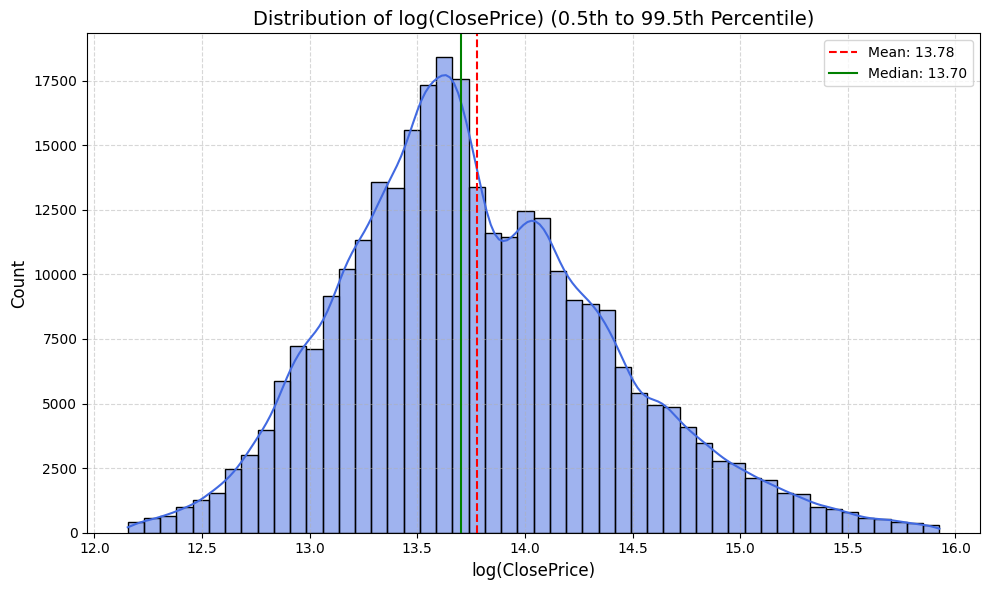

In [231]:
# Calculate cutoffs
lower_pct_val = np.percentile(df_clean['log_ClosePrice'], 0.5)
upper_pct_val = np.percentile(df_clean['log_ClosePrice'], 99.5)

# Filter
trimmed_log_prices = df_clean['log_ClosePrice'][(df_clean['log_ClosePrice'] >= lower_pct_val) & (df_clean['log_ClosePrice'] <= upper_pct_val)]

# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(trimmed_log_prices, kde=True, bins=50, color='royalblue')
plt.axvline(trimmed_log_prices.mean(), color='red', linestyle='--', label=f'Mean: {trimmed_log_prices.mean():.2f}')
plt.axvline(trimmed_log_prices.median(), color='green', linestyle='-', label=f'Median: {trimmed_log_prices.median():.2f}')
plt.title('Distribution of log(ClosePrice) (0.5th to 99.5th Percentile)', fontsize=14)
plt.xlabel('log(ClosePrice)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Log Transformation & Imputation

- **Imputed Missing Boolean Features** (`ViewYN`, `WaterfrontYN`, `PoolPrivateYN`, `FireplaceYN`, `NewConstructionYN`) with `False`.
- **Imputed Missing HOA Details** (`AssociationFeeFrequency` with `'None'`, `AssociationFee` with `0.0`).
- **Log-Transformed** `LivingArea`, `LotSizeSquareFeet`

In [232]:
boolean_cols = ['ViewYN', 'WaterfrontYN', 'PoolPrivateYN', 'FireplaceYN']
for col in boolean_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(False).astype(bool)

# Impute missing values for NewConstructionYN with False
if 'NewConstructionYN' in df_clean.columns:
    df_clean['NewConstructionYN'] = df_clean['NewConstructionYN'].fillna(False).astype(bool)

# Impute missing values for AssociationFeeFrequency with 'None'
if 'AssociationFeeFrequency' in df_clean.columns:
    df_clean['AssociationFeeFrequency'] = df_clean['AssociationFeeFrequency'].fillna('None')

# Impute missing values for AssociationFee with 0.0
if 'AssociationFee' in df_clean.columns:
    df_clean['AssociationFee'] = df_clean['AssociationFee'].fillna(0.0)

# Apply log transformation to LivingArea and LotSizeSquareFeet (using log1p for stability)
if 'LivingArea' in df_clean.columns:
    df_clean['log_LivingArea'] = np.log1p(df_clean['LivingArea'])

if 'LotSizeSquareFeet' in df_clean.columns:
    df_clean['log_LotSizeSquareFeet'] = np.log1p(df_clean['LotSizeSquareFeet'])

df_clean[boolean_cols + ['NewConstructionYN', 'AssociationFeeFrequency', 'AssociationFee', 'log_LivingArea', 'log_LotSizeSquareFeet']].head()

/tmp/ipykernel_2191/3310123916.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].fillna(False).astype(bool)
/tmp/ipykernel_2191/3310123916.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].fillna(False).astype(bool)
/tmp/ipykernel_2191/3310123916.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_

,ViewYN,WaterfrontYN,PoolPrivateYN,FireplaceYN,NewConstructionYN,AssociationFeeFrequency,AssociationFee,log_LivingArea,log_LotSizeSquareFeet
0,False,False,False,True,False,Monthly,140.0,7.571988,8.444622
1,False,False,False,False,False,None,0.0,6.842683,8.836810
2,False,False,False,False,False,None,0.0,7.893199,8.894807
3,True,False,True,False,False,None,0.0,7.244942,8.849371
4,False,False,False,True,False,None,0.0,7.109062,8.949105


## Property Age

In [233]:
# Add PropertyAge column
current_year = 2026
df_clean['PropertyAge'] = current_year - df_clean['YearBuilt']
df_clean['PropertyAge'] = df_clean['PropertyAge'].astype('Int64')  # nullable int, keeps NaN

# Sanity Check
df_clean[['YearBuilt', 'PropertyAge']].head()

,YearBuilt,PropertyAge
0,1985.0,41
1,1970.0,56
2,2008.0,18
3,1952.0,74
4,1985.0,41


In [234]:
# Log transform
df_clean['log_PropertyAge'] = np.log1p(df_clean['PropertyAge'])

# Drop YearBuilt column
df_clean_leakage = df_clean.drop(columns='YearBuilt')

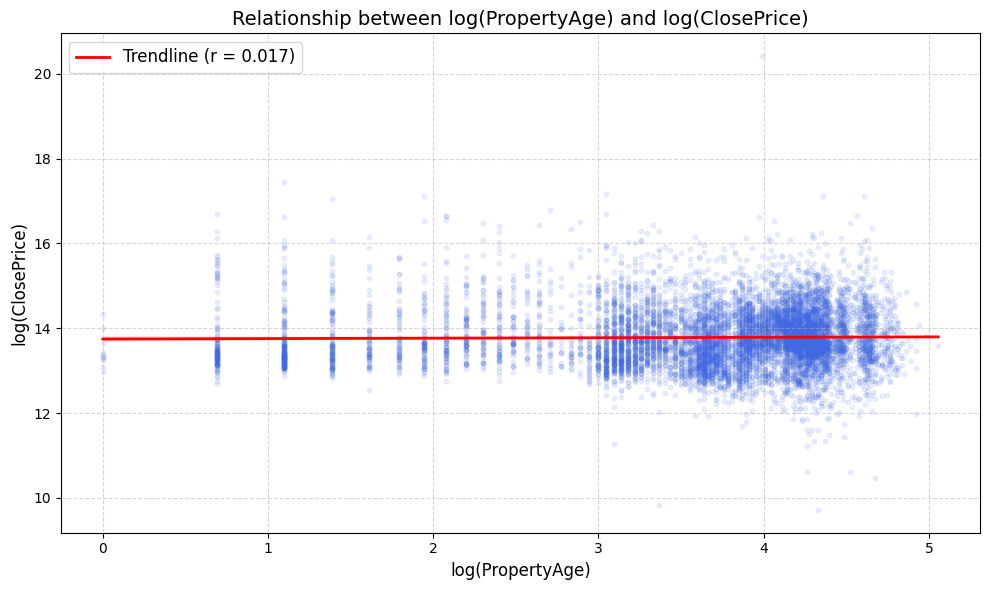

In [235]:
# Drop NaNs in relevant columns to ensure clean plotting
plot_data = df_clean[['log_PropertyAge', 'log_ClosePrice']].dropna()

# Calculate P-correlation coefficient
corr_val = plot_data['log_PropertyAge'].corr(plot_data['log_ClosePrice'])

# Generate a regression plot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=plot_data.sample(n=min(10000, len(plot_data)), random_state=42),  # Subsample for faster rendering
    x='log_PropertyAge',
    y='log_ClosePrice',
    scatter_kws={'alpha': 0.1, 'color': 'royalblue', 's': 10},
    line_kws={'color': 'red', 'linewidth': 2, 'label': f'Trendline (r = {corr_val:.3f})'}
)

plt.title('Relationship between log(PropertyAge) and log(ClosePrice)', fontsize=14)
plt.xlabel('log(PropertyAge)', fontsize=12)
plt.ylabel('log(ClosePrice)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## Listing Seasonality: Sine/Cosine Encoding

To capture when in the year a property was listed, `ListingContractDate` is converted into two cyclical features.

**Why not use the month or day number directly?** A linear encoding treats December 31 (day 365) and January 1 (day 1) as far apart, even though they are consecutive days. Seasonality is cyclical, so the encoding should be too.

**How it works:**
1. Convert each date to the fraction of the year elapsed (0 to 1), adjusting for leap years.
2. Map that fraction onto a circle, where one full year is one full rotation ($2\pi$).
3. Record the position on the circle as two coordinates:

$$\text{ListSeason_sin} = \sin\left(2\pi \cdot \frac{\text{day of year} - 1}{\text{days in year}}\right)$$

$$\text{ListSeason_cos} = \cos\left(2\pi \cdot \frac{\text{day of year} - 1}{\text{days in year}}\right)$$

**Why both features are needed:** sine alone gives the same value for different times of year. Together, sine and cosine give every day a unique position, and the end of the year connects smoothly to the start.

*Going off of 'ListingContractDate' column beacuse that is the effective date of the agreement between the seller and the seller's broker.*

In [236]:
date_col = 'ListingContractDate'
listed = pd.to_datetime(df_clean[date_col], errors='coerce')

# Fraction of the year elapsed, adjusted for leap years
day_of_year = listed.dt.dayofyear
days_in_year = np.where(listed.dt.is_leap_year, 366, 365)
year_frac = (day_of_year - 1) / days_in_year

df_clean['ListSeason_sin'] = np.sin(2 * np.pi * year_frac)
df_clean['ListSeason_cos'] = np.cos(2 * np.pi * year_frac)

df_clean[[date_col, 'ListSeason_sin', 'ListSeason_cos']].head()

,ListingContractDate,ListSeason_sin,ListSeason_cos
0,2023-11-03,-0.849817,0.527078
1,2023-08-31,-0.854322,-0.519744
2,2023-09-12,-0.942761,-0.333469
3,2023-11-16,-0.711657,0.702527
4,2023-10-12,-0.984474,0.175531


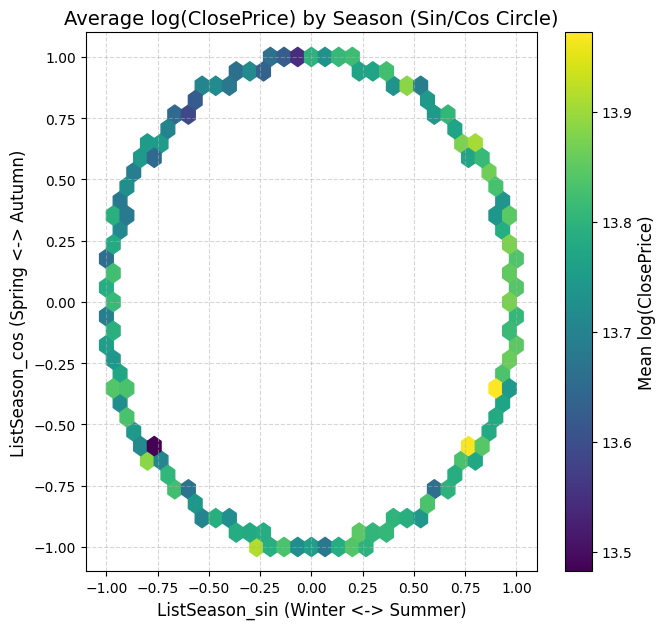

In [237]:
# Drop NaNs
seasonal_data = df_clean[['ListSeason_sin', 'ListSeason_cos', 'log_ClosePrice']].dropna()

# Subsample for smooth rendering
plot_subset = seasonal_data.sample(n=min(30000, len(seasonal_data)), random_state=42)

# Hexbin plot of the unit circle colored by average price
fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1)
hb = ax1.hexbin(
    plot_subset['ListSeason_sin'],
    plot_subset['ListSeason_cos'],
    C=plot_subset['log_ClosePrice'],
    gridsize=30,
    cmap='viridis',
    reduce_C_function=np.mean,
    mincnt=5
)
ax1.set_title('Average log(ClosePrice) by Season (Sin/Cos Circle)', fontsize=14)
ax1.set_xlabel('ListSeason_sin (Winter <-> Summer)', fontsize=12)
ax1.set_ylabel('ListSeason_cos (Spring <-> Autumn)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
cb = fig.colorbar(hb, ax=ax1)
cb.set_label('Mean log(ClosePrice)', fontsize=12)

## School Ratings

Zillow listings show GreatSchools ratings, but for California schools those ratings are
largely built from CAASPP state test results, so I use CAASPP directly instead.

**Aggregation**
1. Geocode each listing's address to latitude and longitude.
2. For each school, average the percent of students meeting or exceeding the standard
   in ELA and Math.
3. Assign each listing the closest elementary, middle, and high school.
4. Average those three school scores into one `school_score` per listing.

Like the CAASPP inputs, `school_score` is on a 0 to 100 scale, which gives the model
finer resolution than GreatSchools' 1 to 10 rating.

In [238]:
!pip install -q geopandas

In [239]:
import io, re, time
import geopandas as gpd
import requests

ADDRESS_COL = 'UnparsedAddress'            # exact street address column
SCHOOLS_FILE = 'pubschls.txt'              # CA Dept. of Education CAASPP Summary Data file
CAASPP_FILE = 'sb_ca2025_all_csv_v1.txt'   # 2025 CA statewide testing results in ELA and Math
GEOCODE_CACHE = 'geocode_results.csv'
EXCLUDE_CHARTERS = True
CHUNK = 2000

df_clean = df_clean.reset_index(drop=True)   # unique index used as geocoder ID
for c in ['Latitude', 'Longitude']:
    df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

In [240]:
# Geocoding from UnparsedAddress to direct lat/long

def geocode_missing(df):
    need = df[df['Latitude'].isna() | df['Longitude'].isna()]
    try:
        geo = pd.read_csv(GEOCODE_CACHE, dtype=str)
        print('Loaded cached geocodes')
    except FileNotFoundError:
        batch = pd.DataFrame({
            'id': need.index,
            'street': need[ADDRESS_COL],
            'city': need['City'],
            'state': need['StateOrProvince'].fillna('CA'),
            'zip': need['PostalCode'].astype(str).str[:5],
        })
        results = []
        for start in range(0, len(batch), CHUNK):
            buf = io.StringIO()
            batch.iloc[start:start + CHUNK].to_csv(buf, header=False, index=False)
            for attempt in range(3):
                try:
                    r = requests.post(
                        'https://geocoding.geo.census.gov/geocoder/locations/addressbatch',
                        files={'addressFile': ('a.csv', buf.getvalue(), 'text/csv')},
                        data={'benchmark': 'Public_AR_Current'},
                        timeout=600,
                    )
                    r.raise_for_status()
                    results.append(pd.read_csv(
                        io.StringIO(r.text), header=None, dtype=str,
                        names=['id', 'input', 'status', 'match_type',
                               'matched', 'coords', 'tiger_id', 'side']))
                    break
                except requests.RequestException as e:
                    print(f'Chunk {start}, attempt {attempt + 1} failed: {e}')
                    time.sleep(10)
            print(f'Geocoded {min(start + CHUNK, len(batch))} / {len(batch)}')
        geo = pd.concat(results, ignore_index=True)
        geo.to_csv(GEOCODE_CACHE, index=False)

    m = geo[geo['status'] == 'Match'].copy()
    m[['lon', 'lat']] = m['coords'].str.split(',', expand=True).astype(float)
    m = m.set_index(m['id'].astype(int))
    df['Latitude'] = df['Latitude'].fillna(m['lat'])
    df['Longitude'] = df['Longitude'].fillna(m['lon'])
    print(geo['status'].value_counts())
    print(f"Still missing coordinates: {df['Latitude'].isna().mean():.1%}")
    return df

df_clean = geocode_missing(df_clean)

Loaded cached geocodes
status
Match       2450
No_Match     232
Tie            9
Name: count, dtype: int64
Still missing coordinates: 0.1%


In [241]:
# Drop latfilled and lonfilled: these True/False flags described the original coordinates
# and no longer apply now that geocoded lat/lon columns have replaced them.
#df_clean = df_clean.drop(columns=['latfilled', 'lonfilled'])

In [242]:
# School Ratings

SCHOOLS_FILE = '/content/drive/MyDrive/IDX Exchange Data Science Internship/Google Colab Notebooks/pubschls.txt'
CAASPP_FILE = '/content/drive/MyDrive/IDX Exchange Data Science Internship/Google Colab Notebooks/sb_ca2025_all_csv_v1.txt'

def load_school_ratings():
    # School directory: locations and levels
    sch = pd.read_csv(SCHOOLS_FILE, sep='\t', dtype=str, encoding='latin-1')
    sch = sch[(sch['StatusType'] == 'Active') &
              sch['EILCode'].isin(['ELEM', 'INTMIDJR', 'HS'])]
    if EXCLUDE_CHARTERS:
        sch = sch[sch['Charter'] != 'Y']
    sch[['Latitude', 'Longitude']] = sch[['Latitude', 'Longitude']].apply(
        pd.to_numeric, errors='coerce')
    sch = sch.dropna(subset=['Latitude', 'Longitude'])

    # Test results: read in chunks, keep all students, all grades, ELA and math
    chunks = []
    for ch in pd.read_csv(CAASPP_FILE, sep='^', dtype=str, encoding='latin-1',
                          chunksize=500_000):
        ch.columns = [re.sub(r'[^a-z]', '', c.lower()) for c in ch.columns]
        ch = ch[(ch['studentgroupid'] == '1') &
                (ch['grade'] == '13') &
                ch['testid'].isin(['1', '2'])]
        chunks.append(ch)
    cs = pd.concat(chunks, ignore_index=True)

    # Build CDS code and average ELA and math
    cs['CDSCode'] = (cs['countycode'].str.zfill(2) +
                     cs['districtcode'].str.zfill(5) +
                     cs['schoolcode'].str.zfill(7))
    cs = cs[~cs['CDSCode'].str.endswith('0000000')]
    cs['pct'] = pd.to_numeric(cs['percentagestandardmetandabove'], errors='coerce')
    ratings = cs.groupby('CDSCode')['pct'].mean().rename('SchoolRating')

    sch = sch.merge(ratings, on='CDSCode', how='inner').dropna(subset=['SchoolRating'])
    print(sch['EILCode'].value_counts())
    return sch

schools = load_school_ratings()

EILCode
ELEM        5213
HS          1533
INTMIDJR    1195
Name: count, dtype: int64


In [243]:
# Blanking out (NaN-ing) coordinates of properties outside of CA for school ranking purposes

pd.set_option('display.float_format', '{:,.1f}'.format)   # no more scientific notation

in_ca = (df_clean['Latitude'].between(32.5, 42.1) &
         df_clean['Longitude'].between(-124.5, -114.1))
print('Coordinates outside California:', (~in_ca & df_clean['Latitude'].notna()).sum())
print(df_clean.loc[~in_ca & df_clean['Latitude'].notna(), ['Latitude', 'Longitude']].head(10))

df_clean.loc[~in_ca, ['Latitude', 'Longitude']] = np.nan

Coordinates outside California: 75
       Latitude  Longitude
5702        1.0        2.0
24090      35.2     -114.0
27072      48.4     -123.4
31911      29.8      -95.1
39449      33.7     -112.4
42830      33.9      118.3
45651      50.0      100.0
46770      10.3      -84.8
47044      34.5      117.4
47435      35.3      120.6


In [244]:
# Adding school rating columns via the closest elem, middle, and high school from each properties lat/long

def add_school_ratings(df, schools):
    has = df['Latitude'].notna() & df['Longitude'].notna()
    props = gpd.GeoDataFrame(
        index=df.index[has],
        geometry=gpd.points_from_xy(df.loc[has, 'Longitude'], df.loc[has, 'Latitude']),
        crs='EPSG:4326').to_crs('EPSG:3310')
    sg = gpd.GeoDataFrame(
        schools[['EILCode', 'SchoolRating']],
        geometry=gpd.points_from_xy(schools['Longitude'], schools['Latitude']),
        crs='EPSG:4326').to_crs('EPSG:3310')

    for level, name in [('ELEM', 'Elem'), ('INTMIDJR', 'Middle'), ('HS', 'High')]:
        lvl = sg.loc[sg['EILCode'] == level, ['SchoolRating', 'geometry']]
        j = gpd.sjoin_nearest(props, lvl, how='left', distance_col='dist')
        j = j[~j.index.duplicated()]
        df[f'{name}SchoolRating'] = j['SchoolRating']
        df[f'{name}SchoolDist_m'] = j['dist']

    df['SchoolRating_missing'] = df['ElemSchoolRating'].isna().astype(int)
    return df

df_clean = add_school_ratings(df_clean, schools)
df_clean[['ElemSchoolRating', 'MiddleSchoolRating', 'HighSchoolRating',
          'ElemSchoolDist_m', 'MiddleSchoolDist_m', 'HighSchoolDist_m']].describe()

,ElemSchoolRating,MiddleSchoolRating,HighSchoolRating,ElemSchoolDist_m,MiddleSchoolDist_m,HighSchoolDist_m
count,"308,829.0","308,829.0","308,829.0","308,829.0","308,829.0","308,829.0"
mean,47.5,41.9,39.9,"1,256.4","2,751.2","2,671.0"
std,20.2,19.5,22.1,"1,579.1","4,100.0","2,844.3"
min,0.0,0.0,0.0,0.8,7.0,0.4
25%,30.9,25.9,24.3,522.3,"1,147.5","1,235.7"
50%,45.7,39.1,40.2,844.3,"1,857.8","1,972.9"
75%,63.8,56.7,57.4,"1,420.7","2,977.1","3,110.4"
max,95.8,92.4,98.6,"105,406.9","130,749.5","130,749.5"


In [245]:
# Dropping the distance to each school in meters after using it as a sanity check
df_clean = df_clean.drop(columns=['ElemSchoolDist_m', 'MiddleSchoolDist_m', 'HighSchoolDist_m'])

### Check for potential collinearity....



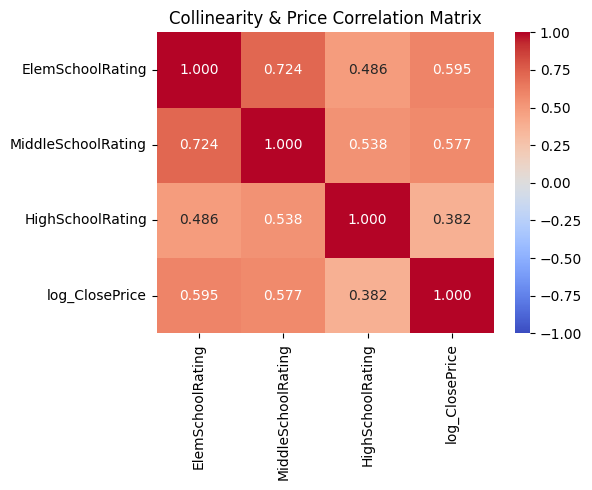

In [246]:
school_cols = ['ElemSchoolRating', 'MiddleSchoolRating', 'HighSchoolRating']
plot_data_schools = df_clean[school_cols + ['log_ClosePrice']].dropna()

# Corr matrix
corr_matrix = plot_data_schools.corr()

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    vmin=-1,
    vmax=1,
    cbar=True
)
plt.title('Collinearity & Price Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.show()

#### Yikes.

### Aggregating School Ratings to Prevent Collinearity

Given the high collinearity between `ElemSchoolRating`, `MiddleSchoolRating`, and `HighSchoolRating`, I will aggregate them into a single overall `SchoolScore` by taking the row-wise mean. This creates a unified representation of school quality and prevents the model from overfitting to redundant features.

In [247]:
# Calculate aggregated SchoolScore as the mean of the three ratings
school_cols = ['ElemSchoolRating', 'MiddleSchoolRating', 'HighSchoolRating']
df_clean['SchoolScore'] = df_clean[school_cols].mean(axis=1)

# Safely update the cleaned leakage dataframe if it is currently in use and contains the school columns
if 'df_clean_leakage' in locals():
    if all(col in df_clean_leakage.columns for col in school_cols):
        df_clean_leakage['SchoolScore'] = df_clean_leakage[school_cols].mean(axis=1)
        df_clean_leakage = df_clean_leakage.drop(columns=school_cols)
    else:
        # If columns are missing, align with df_clean
        df_clean_leakage['SchoolScore'] = df_clean['SchoolScore']

# Drop the individual highly collinear columns :(
df_clean = df_clean.drop(columns=school_cols)

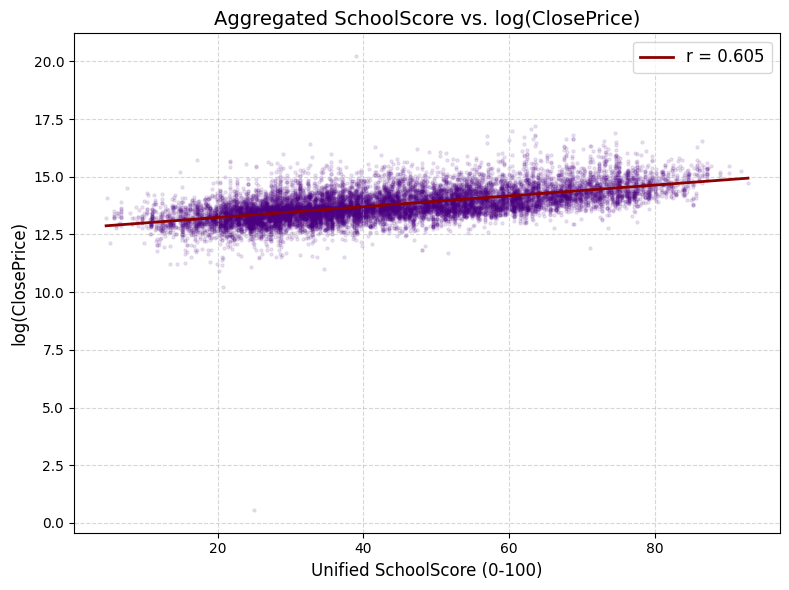

In [248]:
# Prepare data
plot_data_agg = df_clean[['SchoolScore', 'log_ClosePrice']].dropna()
sample_data_agg = plot_data_agg.sample(n=min(15000, len(plot_data_agg)), random_state=42)
corr_score = plot_data_agg['SchoolScore'].corr(plot_data_agg['log_ClosePrice'])

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(
    data=sample_data_agg,
    x='SchoolScore',
    y='log_ClosePrice',
    scatter_kws={'alpha': 0.1, 'color': 'indigo', 's': 5},
    line_kws={'color': 'darkred', 'linewidth': 2, 'label': f'r = {corr_score:.3f}'}
)

plt.title('Aggregated SchoolScore vs. log(ClosePrice)', fontsize=14)
plt.xlabel('Unified SchoolScore (0-100)', fontsize=12)
plt.ylabel('log(ClosePrice)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

#### Yay

In [249]:
# Last touch = log it!
df_clean['log_SchoolScore'] = np.log1p(df_clean['SchoolScore'])

## Other features to be engineered....

## **Initial Round of Dropping Columns:** *92 🔜 60 columns*

To build a robust and generalizable model that works for both on-market and off-market properties, I removed specific classes of columns:

1. **Target Leakage**: Columns like `ListPrice`, `OriginalListPrice`, `DaysOnMarket`, `CloseDate`, and `ContractStatusChangeDate` exist only because a sale process is happening or has completed. Keeping them would be explicit data leakage.
2. **High-Cardinality Categorical Identifiers**: Columns like `UnparsedAddress` (over 300,000 unique values), `ListAgentFullName`, and `ListOfficeName` represent unique entities or system IDs. Keeping these would lead to extreme overfitting and memory issues during modeling without providing generalizable pricing signals.
3. **Unique Keys and System IDs**: Columns like `ListingKey`, `ListingKeyNumeric`, and `ListingId` do not represent physical property features.

In [250]:
# leakage columns to remove
columns_to_remove = [
    'ListPrice',
    'OriginalListPrice',
    'DaysOnMarket',
    'PurchaseContractDate',
    'ListingContractDate',
    'BuyerOfficeName',
    'BuyerAgentMlsId',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',
    'BuyerOfficeAOR',
    'CoBuyerAgentFirstName',
    'BuyerAgentAOR',
    'CloseDate',
    'ListingKey',
    'ListAgentEmail',
    'ListAgentFirstName',
    'ListAgentLastName',
    'PropertyType',
    'CoListAgentFirstName',
    'CoListAgentLastName',
    'ListingKeyNumeric',
    'MlsStatus',
    'PropertySubType',
    'ListingId',
    'ContractStatusChangeDate',
    'BusinessType',
    'StateOrProvince',
    'Levels',
    'OriginatingSystemName',
    'UnparsedAddress',
    'ListAgentFullName',
    'ListOfficeName'
]

# Drop those columns
df_clean_leakage = df_clean.drop(columns=columns_to_remove)

print(f"Removed {len(columns_to_remove)} columns: {columns_to_remove}")
print(f"New DataFrame shape: {df_clean_leakage.shape}")

Removed 32 columns: ['ListPrice', 'OriginalListPrice', 'DaysOnMarket', 'PurchaseContractDate', 'ListingContractDate', 'BuyerOfficeName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerOfficeAOR', 'CoBuyerAgentFirstName', 'BuyerAgentAOR', 'CloseDate', 'ListingKey', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'PropertyType', 'CoListAgentFirstName', 'CoListAgentLastName', 'ListingKeyNumeric', 'MlsStatus', 'PropertySubType', 'ListingId', 'ContractStatusChangeDate', 'BusinessType', 'StateOrProvince', 'Levels', 'OriginatingSystemName', 'UnparsedAddress', 'ListAgentFullName', 'ListOfficeName']
New DataFrame shape: (309145, 62)


## **Next Round of Dropping Columns - Missing Values & Proportions:** 60 🔜 53 columns

In [251]:
n_rows = len(df_clean_leakage)
missing_count = df_clean_leakage.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': (missing_count / n_rows * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

# Drop columns that are truly 100% missing
cols_all_missing = missing_count[missing_count == n_rows].index.tolist()
df_clean_leakage_missing = df_clean_leakage.drop(columns=cols_all_missing)
print(f"Dropped {len(cols_all_missing)} fully empty columns. New shape: {df_clean_leakage_missing.shape}")

pd.reset_option('display.float_format')

print("Columns with more than 70% missing (but not fully empty):")
missing_df[(missing_df['Missing Count'] / n_rows > 0.70) & (missing_df['Missing Count'] < n_rows)]


Dropped 7 fully empty columns. New shape: (309145, 55)
Columns with more than 70% missing (but not fully empty):


,Missing Count,Missing Percentage (%)
BelowGradeFinishedArea,307242,99.38
BasementYN,301709,97.59
BuilderName,294711,95.33
LotSizeDimensions,290350,93.92
BuildingAreaTotal,289609,93.68
OriginatingSystemSubName,276188,89.34
BuyerAgencyCompensation,266969,86.36
BuyerAgencyCompensationType,266955,86.35
ElementarySchool,266797,86.30
MiddleOrJuniorSchool,266467,86.19


## Correlation with Target Variable

In [252]:
import scipy.stats as stats

# Let's identify the target variable and the feature columns
target = 'ClosePrice'
features = [col for col in df_clean_dropped_leakage_missing.columns if col != target]

# We will store correlation statistics here
corr_results = []

for col in features:
    # Clean temporary dataframe for the specific column
    temp = df_clean_dropped_leakage_missing[[col, target]].dropna()
    if len(temp) < 10:
        continue

    # Determine dtype category
    col_series = temp[col]

    if pd.api.types.is_numeric_dtype(col_series):
        # Pearson correlation
        corr_coef, p_val = stats.pearsonr(col_series, temp[target])
        corr_results.append({
            'Feature': col,
            'Type': 'Numeric',
            'Correlation/Strength': corr_coef,
            'P-value': p_val,
            'Method': 'Pearson r'
        })
    elif col_series.nunique() == 2 or col_series.dtype == 'bool':
        # Convert binary/boolean to 1 and 0
        binary_series = col_series.astype(str).str.lower().map({'true': 1, '1': 1, '1.0': 1, 'false': 0, '0': 0, '0.0': 0})
        # Drop any conversion NaNs
        binary_temp = pd.DataFrame({col: binary_series, target: temp[target]}).dropna()
        if len(binary_temp) > 10 and binary_temp[col].nunique() == 2:
            corr_coef, p_val = stats.pointbiserialr(binary_temp[col], binary_temp[target])
            corr_results.append({
                'Feature': col,
                'Type': 'Binary',
                'Correlation/Strength': corr_coef,
                'P-value': p_val,
                'Method': 'Point-Biserial'
            })
    else:
        # High cardinality or multi-class categorical
        # Let's compute Correlation Ratio (Eta) as a measure of association strength
        # Eta = sqrt(SS_between / SS_total)
        groups = [group[target].values for name, group in temp.groupby(col)]
        if len(groups) > 1:
            f_val, p_val = stats.f_oneway(*groups)
            grand_mean = temp[target].mean()
            ss_total = np.sum((temp[target] - grand_mean)**2)
            ss_between = np.sum([len(g) * (np.mean(g) - grand_mean)**2 for g in groups])
            eta = np.sqrt(ss_between / ss_total) if ss_total > 0 else 0
            corr_results.append({
                'Feature': col,
                'Type': 'Categorical',
                'Correlation/Strength': eta,
                'P-value': p_val,
                'Method': 'Correlation Ratio (Eta)'
            })

# Convert results to DataFrame
summary_corr_df = pd.DataFrame(corr_results)
# Sort by absolute correlation strength
summary_corr_df['Abs_Strength'] = summary_corr_df['Correlation/Strength'].abs()
summary_corr_df = summary_corr_df.sort_values(by='Abs_Strength', ascending=False).reset_index(drop=True)

# Calculate cardinality for each feature evaluated in the correlation summary
cardinality_map = {}
for col in summary_corr_df['Feature']:
    # Using df_clean_dropped_leakage_missing to match the subset used during correlation mapping
    if col in df_clean_dropped_leakage_missing.columns:
        cardinality_map[col] = df_clean_dropped_leakage_missing[col].nunique()

# Map cardinality values into summary_corr_df
summary_corr_df['Cardinality'] = summary_corr_df['Feature'].map(cardinality_map)

print("Summary of correlations and association strengths with ClosePrice:")
summary_corr_df

Summary of correlations and association strengths with ClosePrice:


,Feature,Type,Correlation/Strength,P-value,Method,Abs_Strength,Cardinality
0,LotSizeDimensions,Categorical,0.990654,0.000000e+00,Correlation Ratio (Eta),0.990654,9150
1,BuilderName,Categorical,0.867405,0.000000e+00,Correlation Ratio (Eta),0.867405,2668
2,BuildingAreaTotal,Numeric,0.639714,0.000000e+00,Pearson r,0.639714,4721
3,Flooring,Categorical,0.383286,0.000000e+00,Correlation Ratio (Eta),0.383286,323
4,PostalCode,Categorical,0.356707,0.000000e+00,Correlation Ratio (Eta),0.356707,3188
5,SubdivisionName,Categorical,0.334138,2.166362e-01,Correlation Ratio (Eta),0.334138,11855
6,MLSAreaMajor,Categorical,0.264730,0.000000e+00,Correlation Ratio (Eta),0.264730,1070
7,City,Categorical,0.262114,0.000000e+00,Correlation Ratio (Eta),0.262114,1104
8,log_ClosePrice,Numeric,0.258266,0.000000e+00,Pearson r,0.258266,21684
9,CoListOfficeName,Categorical,0.222068,1.000000e+00,Correlation Ratio (Eta),0.222068,4946


# Initial Feature Choices

In [253]:
# Initial feature selection for my design matrix WITH target variable
selected_features = [
    'log_ClosePrice',
    'ViewYN',
    'WaterfrontYN',
    'PoolPrivateYN',
    'AssociationFeeFrequency',
    'BathroomsTotalInteger',
    'BedroomsTotal',
    'FireplaceYN',
    'Stories',
    'NewConstructionYN',
    'GarageSpaces',
    'AssociationFee',
    'log_PropertyAge',
    'ListSeason_sin',
    'ListSeason_cos',
    'log_SchoolScore',
    'log_LivingArea',
    'log_LotSizeSquareFeet'
]

X = df_clean[selected_features]
print(f"Design matrix X shape before one-hot Encoding: {X.shape}")
display(X.head())

Design matrix X shape before one-hot Encoding: (309145, 18)


,log_ClosePrice,ViewYN,WaterfrontYN,PoolPrivateYN,AssociationFeeFrequency,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,Stories,NewConstructionYN,GarageSpaces,AssociationFee,log_PropertyAge,ListSeason_sin,ListSeason_cos,log_SchoolScore,log_LivingArea,log_LotSizeSquareFeet
0,13.726679,False,False,False,Monthly,3.0,4.0,True,2.0,False,2.0,140.0,3.73767,-0.849817,0.527078,3.919429,7.571988,8.444622
1,12.821258,False,False,False,None,2.0,3.0,False,1.0,False,2.0,0.0,4.043051,-0.854322,-0.519744,3.647580,6.842683,8.836810
2,13.208541,False,False,False,None,3.0,4.0,False,2.0,False,3.0,0.0,2.944439,-0.942761,-0.333469,3.276138,7.893199,8.894807
3,13.226723,True,False,True,None,1.0,3.0,False,1.0,False,2.0,0.0,4.317488,-0.711657,0.702527,3.168494,7.244942,8.849371
4,13.190022,False,False,False,None,2.0,3.0,True,1.0,False,2.0,0.0,3.73767,-0.984474,0.175531,3.521742,7.109062,8.949105


In [254]:
# Create a clean copy of the selected features to avoid SettingWithCopyWarnings
X = df_clean[selected_features].copy()

print("Missing values per column in X before final imputation:")
print(X.isnull().sum())

# Impute any remaining missing values in X
# For numeric columns, we will impute with the median
numeric_cols = X.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

# For categorical/boolean columns, we will impute with the mode
cat_bool_cols = X.select_dtypes(exclude=[np.number]).columns
for col in cat_bool_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mode()[0])

# OHE
X_encoded = pd.get_dummies(X, columns=['AssociationFeeFrequency'], drop_first=True)

# Convert boolean columns to integer 0/1 for modeling
bool_cols = X_encoded.select_dtypes(include=['bool']).columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

print("\nDesign matrix shape after one-hot encoding:", X_encoded.shape)
display(X_encoded.head())

Missing values per column in X before final imputation:
log_ClosePrice                 0
ViewYN                         0
WaterfrontYN                   0
PoolPrivateYN                  0
AssociationFeeFrequency        0
BathroomsTotalInteger         50
BedroomsTotal                  0
FireplaceYN                    0
Stories                    39283
NewConstructionYN              0
GarageSpaces               11308
AssociationFee                 0
log_PropertyAge              178
ListSeason_sin                 0
ListSeason_cos                 0
log_SchoolScore              316
log_LivingArea                 0
log_LotSizeSquareFeet       5298
dtype: int64

Design matrix shape after one-hot encoding: (309145, 21)


,log_ClosePrice,ViewYN,WaterfrontYN,PoolPrivateYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,Stories,NewConstructionYN,GarageSpaces,AssociationFee,log_PropertyAge,ListSeason_sin,ListSeason_cos,log_SchoolScore,log_LivingArea,log_LotSizeSquareFeet,AssociationFeeFrequency_Monthly,AssociationFeeFrequency_None,AssociationFeeFrequency_Quarterly,AssociationFeeFrequency_SemiAnnually
0,13.726679,0,0,0,3.0,4.0,1,2.0,0,2.0,140.0,3.73767,-0.849817,0.527078,3.919429,7.571988,8.444622,1,0,0,0
1,12.821258,0,0,0,2.0,3.0,0,1.0,0,2.0,0.0,4.043051,-0.854322,-0.519744,3.647580,6.842683,8.836810,0,1,0,0
2,13.208541,0,0,0,3.0,4.0,0,2.0,0,3.0,0.0,2.944439,-0.942761,-0.333469,3.276138,7.893199,8.894807,0,1,0,0
3,13.226723,1,0,1,1.0,3.0,0,1.0,0,2.0,0.0,4.317488,-0.711657,0.702527,3.168494,7.244942,8.849371,0,1,0,0
4,13.190022,0,0,0,2.0,3.0,1,1.0,0,2.0,0.0,3.73767,-0.984474,0.175531,3.521742,7.109062,8.949105,0,1,0,0


### **Imputation and Preprocessing Strategy Documentation**

Below is a detailed summary of how missing values (`NaN`) and data transformations were handled for each feature in our final design matrix ($X$):

| Feature Name | Feature Type | Imputation Strategy / Transformation |
| :--- | :--- | :--- |
| **ViewYN** | Boolean | Imputed missing values with `False`, then converted to boolean. |
| **WaterfrontYN** | Boolean | Imputed missing values with `False`, then converted to boolean. |
| **PoolPrivateYN** | Boolean | Imputed missing values with `False`, then converted to boolean. |
| **FireplaceYN** | Boolean | Imputed missing values with `False`, then converted to boolean. |
| **NewConstructionYN** | Boolean | Imputed missing values with `False`, then converted to boolean. |
| **AssociationFeeFrequency** | Categorical | Imputed missing values with `'None'` (no HOA), followed by **One-Hot Encoding** (dropped the first category to avoid multi-collinearity). |
| **AssociationFee** | Numeric | Imputed missing values with `0.0`. |
| **BathroomsTotalInteger** | Numeric | Imputed missing values ($50$ rows) with the column **median**. |
| **Stories** | Numeric | Imputed missing values ($39,283$ rows) with the column **median**. |
| **GarageSpaces** | Numeric | Imputed missing values ($11,308$ rows) with the column **median**. |
| **log_PropertyAge** | Numeric | Engineered using `2026 - YearBuilt`, transformed via $\log(1 + \text{PropertyAge})$ to stabilize skew. Missing values ($178$ rows) were imputed with the **median**. |
| **log_SchoolScore** | Numeric | Unified from ELA/Math test standards across nearest schools and transformed via $\log(1 + \text{SchoolScore})$. Missing values ($316$ rows) were imputed with the **median**. |
| **log_LivingArea** | Numeric | Transformed via $\log(1 + \text{LivingArea})$ to handle right skew; had no missing values. |
| **log_LotSizeSquareFeet** | Numeric | Transformed via $\log(1 + \text{LotSizeSquareFeet})$. Missing values ($5,298$ rows) were imputed with the **median**. |
| **ListSeason_sin** / **cos** | Numeric (Cyclical) | Trigonometrically encoded from `ListingContractDate` to capture cyclical seasonality; had no missing values. |

# Train/Test Split

### **Chronological Train/Test Split & Cross-Validation Strategy**

* **Test Set (Last 2 Months):** All listings with a `CloseDate` falling within the final two calendar months of our dataset.
* **Training/Validation Set:** The remaining (earlier) data serves as our development set.
* **5-Fold Cross-Validation:** The training set is split into 5 chronological folds to preserve temporal integrity during hyperparameter tuning and model optimization.

*Note: Because `X_encoded` and `y` both inherit matching, unique index identifiers from `df_clean`, slicing them with identical boolean split masks (`is_train` and `is_test`) guarantees that the features and targets remain perfectly synchronized under pandas' index alignment system.*

In [255]:
from sklearn.model_selection import KFold

# Ensure CloseDate is a datetime series to align with df_clean
close_dates = pd.to_datetime(df_clean['CloseDate'])
max_date = close_dates.max()

# Define the test split threshold as exactly 2 months prior to the maximum closing date
test_start_date = max_date - pd.DateOffset(months=2)
print(f"Latest CloseDate in dataset: {max_date.strftime('%Y-%m-%d')}")
print(f"Test set start threshold (last 2 months): {test_start_date.strftime('%Y-%m-%d')}\n")

# Create train and test boolean masks
is_test = close_dates >= test_start_date
is_train = ~is_test

# Target Variable
y = X_encoded['log_ClosePrice']

X_train, X_test = X_encoded.iloc[:, 1:][is_train].copy(), X_encoded.iloc[:, 1:][is_test].copy()
y_train, y_test = y[is_train].copy(), y[is_test].copy()

print(f"Training set shape: {X_train.shape} (from {close_dates[is_train].min().strftime('%Y-%m-%d')} to {close_dates[is_train].max().strftime('%Y-%m-%d')})")
print(f"Test set shape:     {X_test.shape} (from {close_dates[is_test].min().strftime('%Y-%m-%d')} to {close_dates[is_test].max().strftime('%Y-%m-%d')})")

# Define 5-Fold Cross Validation for the Training Set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nSuccessfully defined a 5-fold cross-validation scheme over the {len(X_train)} training observations.")

Latest CloseDate in dataset: 2026-04-30
Test set start threshold (last 2 months): 2026-02-28

Training set shape: (285115, 20) (from 2024-01-01 to 2026-02-27)
Test set shape:     (24030, 20) (from 2026-02-28 to 2026-04-30)

Successfully defined a 5-fold cross-validation scheme over the 285115 training observations.


In [256]:
# Sanity check
for i, (tr, va) in enumerate(kf.split(X_train), start=1):
    print(f"Fold {i}: train = {len(tr):,} rows, validation = {len(va):,} rows")

Fold 1: train = 228,092 rows, validation = 57,023 rows
Fold 2: train = 228,092 rows, validation = 57,023 rows
Fold 3: train = 228,092 rows, validation = 57,023 rows
Fold 4: train = 228,092 rows, validation = 57,023 rows
Fold 5: train = 228,092 rows, validation = 57,023 rows


### Fold 1 Design Matrix and Target Vector

In [257]:
# Get the index splits for Fold 1
train_idx, val_idx = next(kf.split(X_train))

# Extract the subsets for Fold 1
X_fold1_train = X_train.iloc[train_idx]
y_fold1_train = y_train.iloc[train_idx]

print("--- Fold 1 X (Features) Head ---")
display(X_fold1_train.head())

print("\n--- Fold 1 y (Target) Head ---")
display(y_fold1_train.head())

--- Fold 1 X (Features) Head ---


,ViewYN,WaterfrontYN,PoolPrivateYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,Stories,NewConstructionYN,GarageSpaces,AssociationFee,log_PropertyAge,ListSeason_sin,ListSeason_cos,log_SchoolScore,log_LivingArea,log_LotSizeSquareFeet,AssociationFeeFrequency_Monthly,AssociationFeeFrequency_None,AssociationFeeFrequency_Quarterly,AssociationFeeFrequency_SemiAnnually
1,0,0,0,2.0,3.0,0,1.0,0,2.0,0.0,4.043051,-0.854322,-0.519744,3.647580,6.842683,8.836810,0,1,0,0
2,0,0,0,3.0,4.0,0,2.0,0,3.0,0.0,2.944439,-0.942761,-0.333469,3.276138,7.893199,8.894807,0,1,0,0
3,1,0,1,1.0,3.0,0,1.0,0,2.0,0.0,4.317488,-0.711657,0.702527,3.168494,7.244942,8.849371,0,1,0,0
4,0,0,0,2.0,3.0,1,1.0,0,2.0,0.0,3.73767,-0.984474,0.175531,3.521742,7.109062,8.949105,0,1,0,0
5,1,0,1,7.0,6.0,1,2.0,0,3.0,750.0,3.401197,-0.552435,0.833556,4.231276,8.418036,9.436759,1,0,0,0



--- Fold 1 y (Target) Head ---


,log_ClosePrice
1,12.821258
2,13.208541
3,13.226723
4,13.190022
5,15.983993
